# Support Vector Machines
## SVM - Regressie

Deze proef meet de consistentie van vers beton voordat het uithardt, door te kijken hoeveel beton inzakt. Het wordt uitgevoerd om de verwerkbaarheid van pasgemaakt beton te controleren, en daarmee de mate waarin het beton vloeit. Het kan ook gebruikt worden als een indicatie van een onjuist gemengde partij. De zetmaat is het aantal mm dat betonspecie inzakt nadat een standaardkegel met die specie, die op een plat vlak staat, omhoog is getrokken. Het gaat om het aantal mm dat de kegel ingezakt is, dus hoe hoger de zetmaat hoe vloeibaarder de betonspecie (tekening onder)

Onze dataset bestaat uit verschillende eigenschappen van cement en de resulterende zaktestmetrieken in cm. Later wordt het uitgeharde beton getest op zijn druksterkte na 28 dagen.

Invoervariabelen (7) (component kg in één m³ beton):
* Cement
* Slag
* Fly ash
* Water
* SP
* Coarse Aggr.
* Fine Aggr.

Output variabelen (3):
* SLUMP (cm)
* FLOW (cm)
* **28-day Compressive Strength (Mpa)**

Data afkomstig van: https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test

*Credit: Yeh, I-Cheng, "Modeling slump flow of concrete using second-order regressions and artificial neural networks," Cement and Concrete Composites, Vol.29, No. 6, 474-480, 2007.*

In [1]:
from IPython.core.display import HTML

# Maak een HTML string met de gewenste layout
html = """
<table>
<tr>
<td><img src="Types_of_concrete_slump.jpg" width='200'></td>
<td><img src="betonproef.png" width='200'></td>
<td><img src="betonproef_kegel.png" width='200'></td>
<td><img src="betonproef_voorbeeld.png" width='200'></td>
</tr>
</table>
"""

# Display HTML
display(HTML(html))

,,,


Kunnen we de druksterkte van het beton voorspellen aan de hand van de input parameters op het ogenblik van het mengen en de resultaten van de zaktest?

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/cement_slump.csv')

In [4]:
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


In [5]:
df.corr()['Compressive Strength (28-day)(Mpa)']

Cement                                0.445656
Slag                                 -0.331522
Fly ash                               0.444380
Water                                -0.254320
SP                                   -0.037909
Coarse Aggr.                         -0.160610
Fine Aggr.                           -0.154532
SLUMP(cm)                            -0.223499
FLOW(cm)                             -0.124189
Compressive Strength (28-day)(Mpa)    1.000000
Name: Compressive Strength (28-day)(Mpa), dtype: float64

<Axes: >

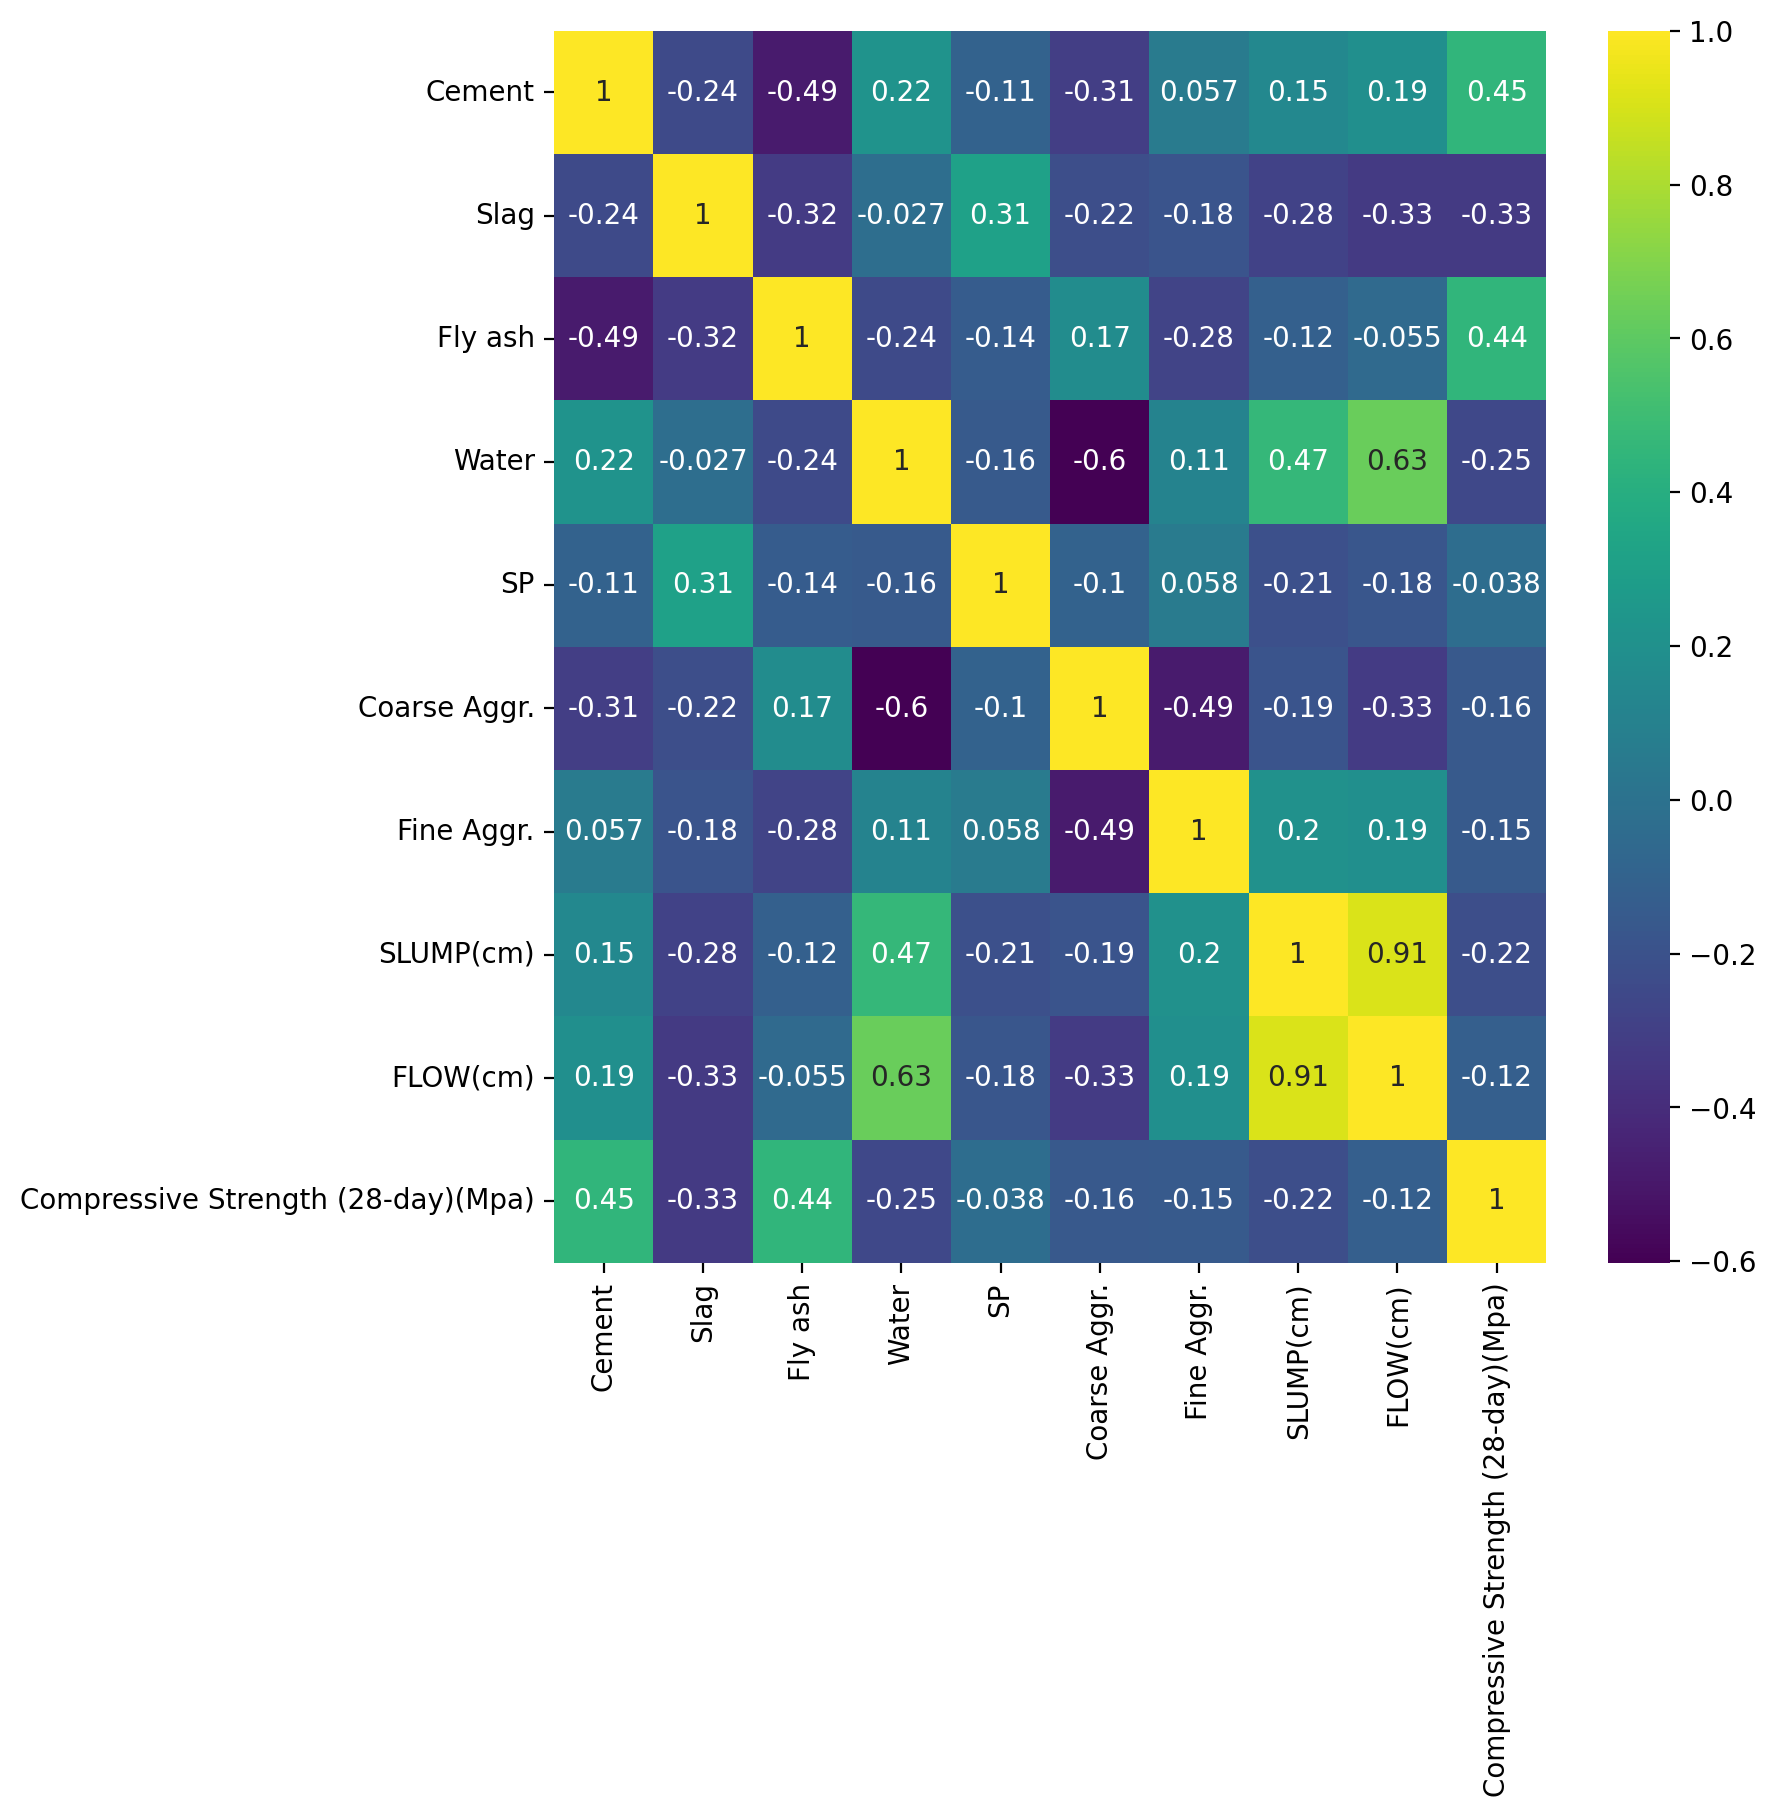

In [6]:
plt.figure(figsize=(8,8), dpi=200)
sns.heatmap(df.corr(),cmap='viridis', annot=True)

In [7]:
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='object')

## Train | Test Split

In [8]:
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='object')

In [9]:
X = df.drop('Compressive Strength (28-day)(Mpa)',axis=1)
y = df['Compressive Strength (28-day)(Mpa)']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Voor elk algoritme dat naar afmetingen in een feature space kijkt, moeten we scalen.  Bij SVM is dit zeker zo; vaak gaan we zelfs naar hogere dimensies!

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

In [14]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

y_test.mean()## Support Vector Machines - Regressie

Er zijn drie verschillende implementaties van Support Vector Regression: SVR, NuSVR en LinearSVR. LinearSVR biedt een snellere implementatie dan SVR, maar houdt alleen rekening met de lineaire kernel, terwijl NuSVR een iets andere formule implementeert dan SVR en LinearSVR. Wanneer je dus geen kernel gebruikt kies je LinearSVR, anders SVR.  NuSVR is een alternatief voor SVR waarbij je meer controle hebt over bijvoorbeeld het aantal Support Vectors.  De parameter nu in NuSVR geeft een benadering van de fractie van de support vectors in verhouding tot het totale aantal vectoren.  In situaties waar rekenbronnen beperkt zijn, kan het beperken van het aantal support vectors helpen om de voorspellingssnelheid te verhogen, omdat de complexiteit van een SVM-model grotendeels afhankelijk is van het aantal support vectors.  In dezelfde zin kan het beperken van het aantal support vectors overfitting verminderen.  

Zie [Implementatie details](https://scikit-learn.org/stable/modules/svm.html#svm-implementation-details) voor meer informatie.

In [15]:
from sklearn.svm import SVR,LinearSVR

We kunnen een kernel kiezen (default 'rbf), een degree (polynomial), een gamma, een C (default 1) - het instellen van C: C is standaard 1 en dat is een redelijke standaardkeuze. Als je veel grillige observaties hebt, moet je C verlagen: een lagere C komt overeen met meer regularisatie.

LinearSVC en LinearSVR zijn minder gevoelig voor C wanneer deze groot wordt, en de voorspellingsresultaten stoppen met verbeteren na een bepaalde drempel. Ondertussen zullen grotere C-waarden meer tijd in beslag nemen om te trainen, soms tot wel 10 keer langer.

Epsilon: https://stats.stackexchange.com/questions/259018/meaning-of-epsilon-in-svm-regression

Epsilon is een parameter die wordt gebruikt bij het trainen van een SVR model. Epsilon bepaalt hoe tolerant het model is.  Deze tolerantie zorgt voor meer bias, en dus een beter generaliserend model.  Ook epsilon wordt via Grid search bepaald. 

Epsilon (ε) is een parameter die de breedte van de ε-band rond de regressielijn definieert. Binnen deze band worden fouten niet bestraft, wat betekent dat alle punten binnen deze marge als correct worden beschouwd door het model, ongeacht of ze precies op de regressielijn liggen. Dit concept is cruciaal in SVR omdat het helpt bij het bepalen van de mate van tolerantie voor fouten tegenover de voorspellingen van het model.

Het belangrijkste doel van epsilon is om overfitting te verminderen en de generalisatie van het model te verbeteren. Door de epsilon-waarde aan te passen, kun je beïnvloeden hoe gevoelig het model is voor trainingssamples die dicht bij de werkelijke regressielijn liggen:

Een **kleine** epsilon-waarde leidt tot een **smaller gebied rond de regressielijn**, wat betekent dat meer datapunten als fouten zullen worden beschouwd en dus de modelcomplexiteit kan toenemen omdat het meer gevoelig is voor de training data.  

Een **grote** epsilon-waarde creëert een **breder gebied rond de regressielijn**, waardoor minder datapunten als fouten worden beschouwd. Dit kan helpen om overfitting te verminderen, omdat het model minder gevoelig is voor kleine fluctuaties in de trainingsdata.  

De keuze van epsilon is dus een belangrijke afweging in SVR-modellen, omdat het een directe impact heeft op de prestaties en de complexiteit van het model. Het vinden van de optimale epsilon-waarde is vaak een kwestie van experimentatie en validatie om de beste balans tussen bias en variantie, specifiek voor de gegeven dataset, te bereiken.

<img src="epsilon.png" width='200'></td>

In [16]:
base_model = SVR() # basis model!

In [17]:
base_model.fit(scaled_X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [18]:
base_preds = base_model.predict(scaled_X_test)

## Evaluatie

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
mean_absolute_error(y_test,base_preds)

5.236902091259178

In [21]:
np.sqrt(mean_squared_error(y_test,base_preds))

np.float64(6.695914838327133)

In [22]:
y_test.mean()

np.float64(36.26870967741935)

## Grid Search om het model mogelijk te verbeteren

In [23]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1],
             'kernel':['linear','rbf','poly'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0,0.01,0.1,0.5,1,2]}

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
svr = SVR()
grid = GridSearchCV(svr,param_grid=param_grid)

In [26]:
grid.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [2, 3, ...], 'epsilon': [0, 0.01, ...], 'gamma': ['scale', 'auto'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [27]:
grid.best_params_

{'C': 1, 'degree': 2, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}

In [28]:
grid_preds = grid.predict(scaled_X_test)

In [29]:
mean_absolute_error(y_test,grid_preds)

2.5128012210762365

In [30]:
np.sqrt(mean_squared_error(y_test,grid_preds))

np.float64(3.178210305119858)

Dit is een grote verbetering!